# Download Dataset

In [ ]:
import kagglehub

# Download latest version
# https://universe.roboflow.com/crackdataannotations/cracks-yolo-nas
path = kagglehub.dataset_download("danishghaffar786/roads-and-bridges-cracks-yolov8-format")

print("Path to dataset files:",path)

df_caminho = "/kaggle/input/roads-and-bridges-cracks-yolov8-format"

Using Colab cache for faster access to the 'roads-and-bridges-cracks-yolov8-format' dataset.
Path to dataset files: /kaggle/input/roads-and-bridges-cracks-yolov8-format


# Importação Bibliotecas

In [2]:
!pip install ultralytics --quiet
import ultralytics
import torch
import gc
import os
import glob
import random
import yaml
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO
from PIL import Image, ImageDraw
from google.colab import drive

drive.mount('/content/drive')
ultralytics.checks()

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.4/107.7 GB disk)


# Indexação De Caminhos

In [ ]:
test_img_dir = f"{df_caminho}/test/images"
test_label_dir = f"{df_caminho}/test/labels"
yaml_caminho = f"{df_caminho}/data.yaml"

with open(yaml_caminho, "r", encoding="utf-8") as f:
    yaml = yaml.safe_load(f)

classes_nome = yaml["names"]

print(test_img_dir)
print(test_label_dir)
print(classes_nome)

/kaggle/input/roads-and-bridges-cracks-yolov8-format/test/images
/kaggle/input/roads-and-bridges-cracks-yolov8-format/test/labels
['cracks']


# Visulização Das Imagens No DataSet

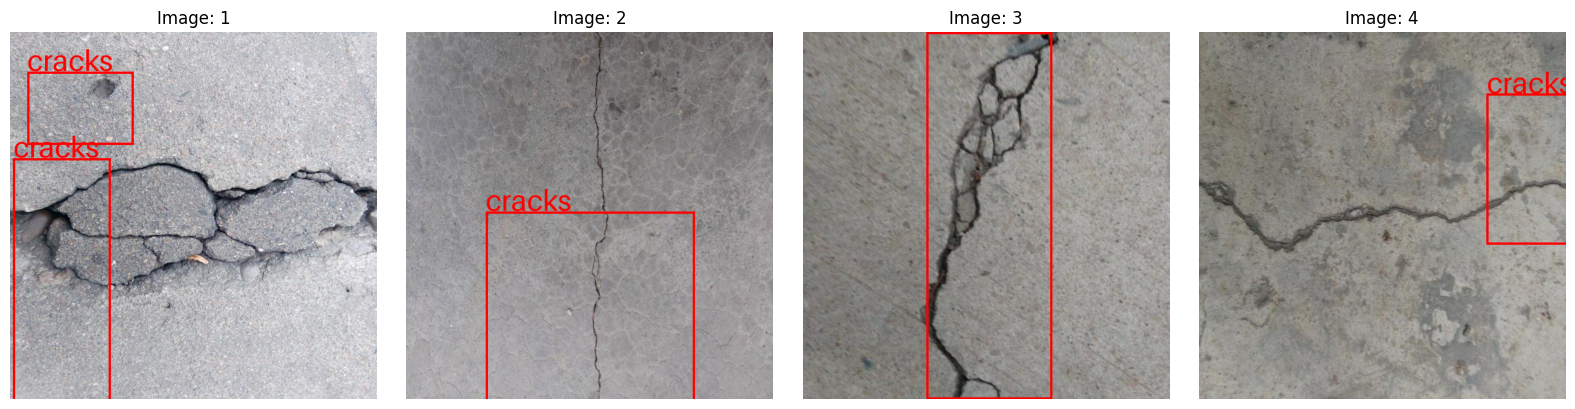

In [ ]:
# Selecionar 4 imagens aleatórias
image_files = [f for f in os.listdir(test_img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
sample_images = random.sample(image_files, 4)

plt.figure(figsize=(16, 4))

for i, img_file in enumerate(sample_images):
    # Caminhos da imagem e do label
    img_path = os.path.join(test_img_dir, img_file)
    label_path = os.path.join(test_label_dir, os.path.splitext(img_file)[0] + '.txt')

    # Abrir imagem
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    w, h = img.size
    font_size = max(int(w * 0.08), 12)
    # Desenhar bounding boxes e classes
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                class_id = int(parts[0])
                x_center, y_center, box_w, box_h = map(float, parts[1:5])
                x1 = (x_center - box_w / 2) * w
                y1 = (y_center - box_h / 2) * h
                x2 = (x_center + box_w / 2) * w
                y2 = (y_center + box_h / 2) * h

                # Caixa
                draw.rectangle([x1, y1, x2, y2], outline='red', width=4)

                # Texto da classe (acima da caixa)
                classe = classes_nome[class_id] if class_id < len(classes_nome) else f"Classe {class_id}"
                draw.text((x1, y1-font_size), classe, fill='red', font_size=font_size)

    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title('Image: ' + str(i+1))

plt.tight_layout()
plt.show()

In [ ]:
gc.collect()  # limpa objetos Python não utilizados
torch.cuda.empty_cache()  # limpa cache CUDA

# Treino


In [ ]:
# %%capture

# qtd_imgs = 1441
# qtd de imagens a serem processadas simultaneamente antes da atualização de pesos
batch_ = 25

# qtd de vezes que percorre as imagens de treinamento
epochs_ = 100
patience_ = 25

# novas dimensões das imagens no treinamento
# imgsz_ = 640
imgsz_ = 160

modelos_yolo = [
    "yolo26n.pt",
    "yolo26s.pt",
    "yolo26m.pt",
]

for modelo in modelos_yolo:
  modelo_yolo = YOLO(modelo)
  modelo_yolo.train(data=yaml_caminho,
              batch=batch_,
              epochs=epochs_,
              imgsz=imgsz_,
              patience=patience_,
              project="/content/drive/MyDrive/YOLO/",
              name=f"classificacao-rachaduras-({modelo.replace(".pt","")})")

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=25, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/roads-and-bridges-cracks-yolov8-format/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=160, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=classificacao-rachaduras-(yolo26n)-3, nbs=64, nms=False, opset=None,

KeyboardInterrupt: 

# Resultados

Downloading...
From: https://drive.google.com/uc?id=1jArS1ig5cD4P7hV94tI-feQYLvgUncT6
To: /content/results.png
100% 302k/302k [00:00<00:00, 102MB/s]


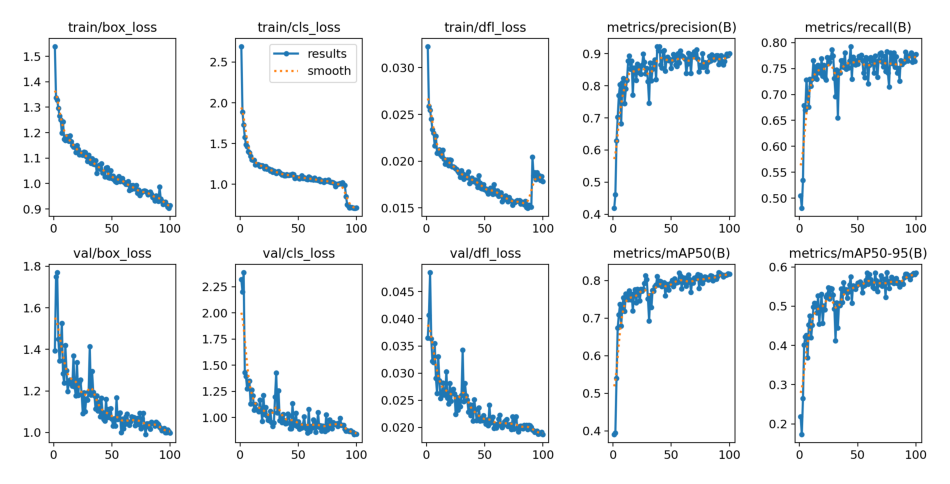

In [5]:
!gdown 1jArS1ig5cD4P7hV94tI-feQYLvgUncT6
resultados_img = "/content/results.png"

img = Image.open(resultados_img)

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.show()